# 04 — Random Forest avec Analyse de Proximité
**Membre 2** | Credit Card Fraud Detection

### Ce notebook produit :
- Modèle Random Forest optimisé
- `models/random_forest.pkl`
- Matrice de proximité + analyse des outliers de prédiction

### Plan :
1. Chargement des données
2. Hyperparameter Tuning (RandomizedSearchCV)
3. Entraînement du modèle final
4. Évaluation complète
5. Extraction de la matrice de proximité
6. Détection et analyse des outliers de prédiction
7. Sauvegarde

> **Note T490s :** La matrice de proximité NxN est impossible sur 200k lignes.  
> On travaille sur un échantillon de 5,000 observations — justifié dans le rapport.

---
## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.metrics         import (
    f1_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc
)

# ── Config ────────────────────────────────────────────────────────
RANDOM_SEED = 42
TRAIN_PATH  = '../data/processed/train.csv'
VAL_PATH    = '../data/processed/val.csv'
TEST_PATH   = '../data/processed/test.csv'
MODELS_PATH = '../models/'
PLOTS_PATH  = '../plots/'
PROX_SAMPLE = 5000  # Taille échantillon pour matrice de proximité

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH,  exist_ok=True)
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Setup OK')

✅ Setup OK


---
## 1. Chargement des Données

In [2]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

X_train = train.drop(columns=['Class'])
y_train = train['Class']
X_val   = val.drop(columns=['Class'])
y_val   = val['Class']
X_test  = test.drop(columns=['Class'])
y_test  = test['Class']

print('═══════════════════════════════════════════════')
for name, X, y in [('Train',X_train,y_train),
                    ('Val',X_val,y_val),
                    ('Test',X_test,y_test)]:
    print(f'  {name:<6}: {len(X):>8,} lignes | {y.sum():>4} fraudes ({y.mean()*100:.3f}%)')
print('═══════════════════════════════════════════════')

═══════════════════════════════════════════════
  Train :  205,060 lignes |  355 fraudes (0.173%)
  Val   :   22,785 lignes |   39 fraudes (0.171%)
  Test  :   56,962 lignes |   98 fraudes (0.172%)
═══════════════════════════════════════════════


---
## 2. Hyperparameter Tuning — RandomizedSearchCV

| Hyperparamètre | Espace | Justification |
|---|---|---|
| `n_estimators` | [100, 200, 300] | Plus d'arbres = meilleure généralisation, mais coût mémoire |
| `max_depth` | [10, 20, 30, None] | Contrôle l'overfitting — None = arbres complets |
| `min_samples_split` | [2, 5, 10] | Nombre minimum d'observations pour diviser un nœud |
| `min_samples_leaf` | [1, 2, 4] | Taille minimum d'une feuille — régularisation |
| `max_features` | ['sqrt', 'log2'] | Nombre de features candidates à chaque split |

In [3]:
param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
}

base_rf = RandomForestClassifier(
    class_weight = 'balanced',
    random_state = RANDOM_SEED,
    n_jobs       = -1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print('RandomizedSearchCV en cours... (peut prendre 10-20 min sur T490s)')
random_search = RandomizedSearchCV(
    estimator          = base_rf,
    param_distributions= param_dist,
    n_iter             = 20,
    cv                 = cv,
    scoring            = 'average_precision',
    n_jobs             = -1,
    verbose            = 1,
    random_state       = RANDOM_SEED,
    refit              = True
)
random_search.fit(X_train, y_train)
print('✅ RandomizedSearchCV terminé')
print(f'\nMeilleurs paramètres : {random_search.best_params_}')
print(f'Meilleur AUPRC (CV)  : {random_search.best_score_:.4f}')

RandomizedSearchCV en cours... (peut prendre 10-20 min sur T490s)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ RandomizedSearchCV terminé

Meilleurs paramètres : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Meilleur AUPRC (CV)  : 0.8516


---
## 3. Entraînement du Modèle Final

In [4]:
best_rf = random_search.best_estimator_

print('═══════════════════════════════════════════════')
print('         MODÈLE FINAL — PARAMÈTRES            ')
print('═══════════════════════════════════════════════')
for k, v in random_search.best_params_.items():
    print(f'  {k:<25}: {v}')
print(f'  {"class_weight":<25}: balanced')
print('═══════════════════════════════════════════════')

═══════════════════════════════════════════════
         MODÈLE FINAL — PARAMÈTRES            
═══════════════════════════════════════════════
  n_estimators             : 200
  min_samples_split        : 2
  min_samples_leaf         : 2
  max_features             : sqrt
  max_depth                : None
  class_weight             : balanced
═══════════════════════════════════════════════


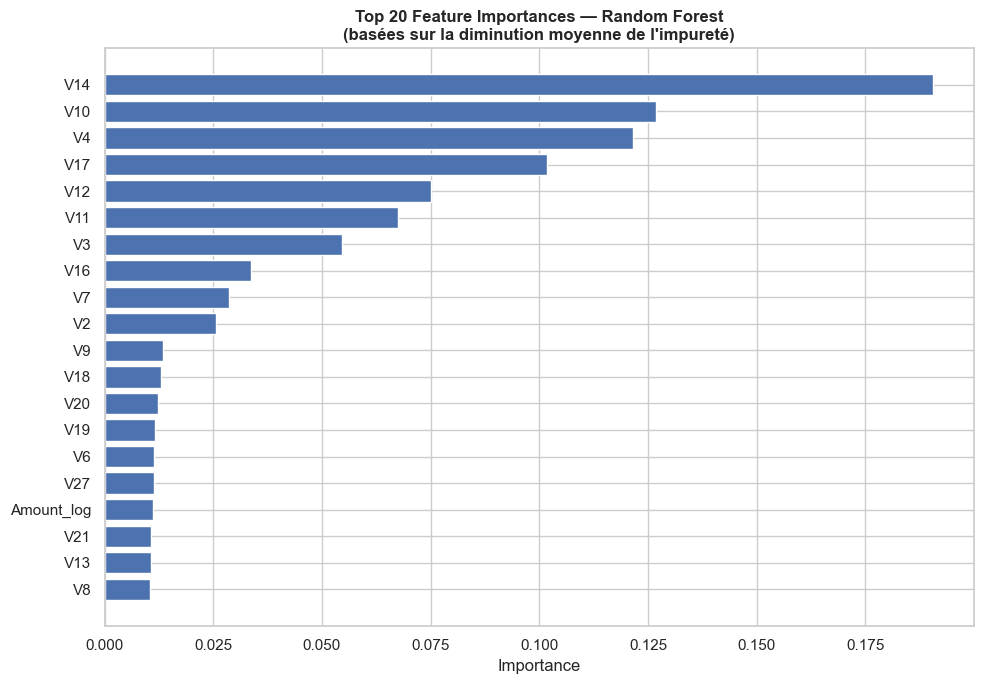

Top 10 features :
Feature  Importance
    V14    0.190469
    V10    0.126795
     V4    0.121463
    V17    0.101811
    V12    0.075042
    V11    0.067557
     V3    0.054604
    V16    0.033780
     V7    0.028626
     V2    0.025527


In [5]:
# Importance des features
feature_names = X_train.columns.tolist()
importances   = best_rf.feature_importances_
feat_imp_df   = pd.DataFrame({'Feature': feature_names,
                               'Importance': importances})
feat_imp_df   = feat_imp_df.sort_values('Importance', ascending=False)

top20 = feat_imp_df.head(20)
plt.figure(figsize=(10, 7))
plt.barh(top20['Feature'][::-1], top20['Importance'][::-1],
         color='#4C72B0', edgecolor='white')
plt.title('Top 20 Feature Importances — Random Forest\n'
          '(basées sur la diminution moyenne de l\'impureté)',
          fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}17_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features :')
print(feat_imp_df.head(10).to_string(index=False))

---
## 4. Évaluation Complète

In [6]:
def evaluate(y_true, y_pred, y_proba, label=''):
    f1    = f1_score(y_true, y_pred, average='macro')
    auprc = average_precision_score(y_true, y_proba)
    mcc   = matthews_corrcoef(y_true, y_pred)
    f1_fraud  = f1_score(y_true, y_pred, average=None)[1]
    recall    = (y_pred[y_true==1]==1).mean()
    precision = (y_true[y_pred==1]==1).mean() if (y_pred==1).sum()>0 else 0
    print(f'\n══════════════════════════════════════════')
    print(f'  {label}')
    print(f'══════════════════════════════════════════')
    print(f'  F1-Macro  : {f1:.4f}')
    print(f'  AUPRC     : {auprc:.4f}')
    print(f'  MCC       : {mcc:.4f}')
    print(f'  F1-Fraude : {f1_fraud:.4f}')
    print(f'  Rappel    : {recall:.4f}  ({int(recall*y_true.sum())}/{y_true.sum()} fraudes)')
    print(f'  Précision : {precision:.4f}')
    return {'Label':label,'F1-Macro':f1,'AUPRC':auprc,'MCC':mcc,
            'F1-Fraude':f1_fraud,'Rappel':recall,'Precision':precision}

y_val_pred   = best_rf.predict(X_val)
y_val_proba  = best_rf.predict_proba(X_val)[:,1]
res_val = evaluate(y_val, y_val_pred, y_val_proba, 'Validation Set')

y_test_pred  = best_rf.predict(X_test)
y_test_proba = best_rf.predict_proba(X_test)[:,1]
res_test = evaluate(y_test, y_test_pred, y_test_proba, 'Test Set (FINAL)')


══════════════════════════════════════════
  Validation Set
══════════════════════════════════════════
  F1-Macro  : 0.9142
  AUPRC     : 0.7936
  MCC       : 0.8338
  F1-Fraude : 0.8286
  Rappel    : 0.7436  (29/39 fraudes)
  Précision : 0.9355

══════════════════════════════════════════
  Test Set (FINAL)
══════════════════════════════════════════
  F1-Macro  : 0.9269
  AUPRC     : 0.8624
  MCC       : 0.8581
  F1-Fraude : 0.8539
  Rappel    : 0.7755  (76/98 fraudes)
  Précision : 0.9500


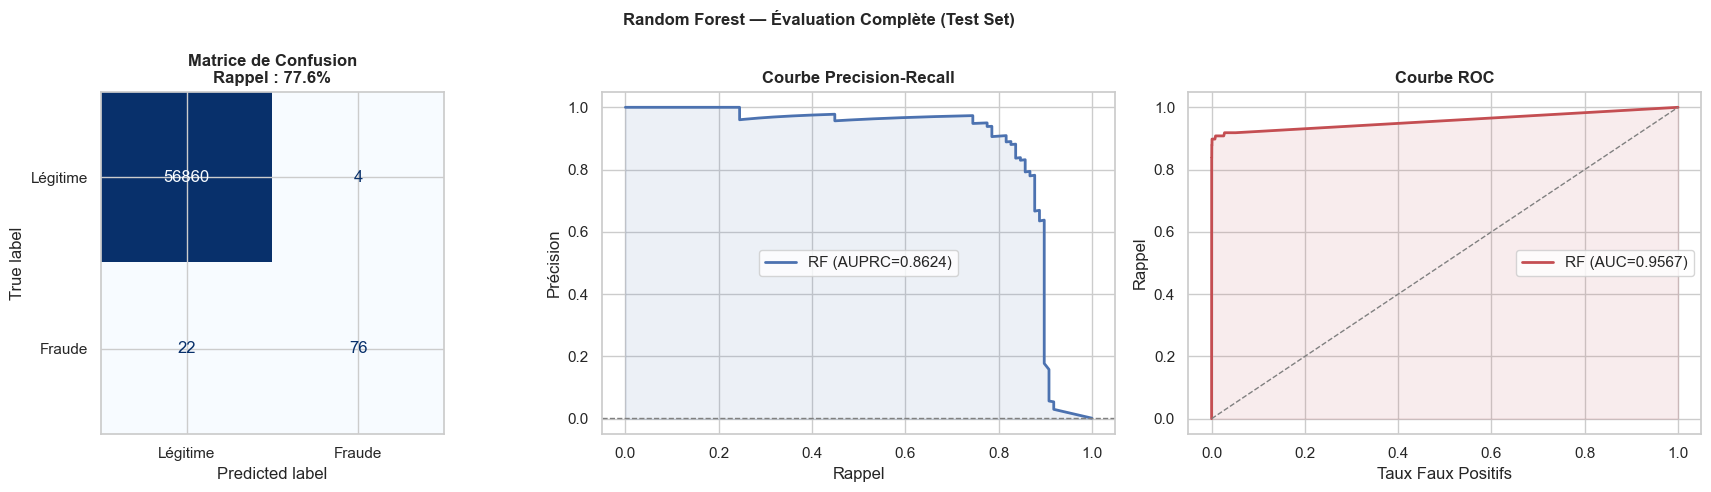

In [7]:
# Matrice de confusion + courbes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['Légitime','Fraude']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
tp, fn = cm[1,1], cm[1,0]
axes[0].set_title(f'Matrice de Confusion\nRappel : {tp/(tp+fn):.1%}', fontweight='bold')

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_test_proba)
auprc_score  = average_precision_score(y_test, y_test_proba)
axes[1].plot(rec, prec, color='#4C72B0', lw=2,
             label=f'RF (AUPRC={auprc_score:.4f})')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1)
axes[1].fill_between(rec, prec, alpha=0.1, color='#4C72B0')
axes[1].set_xlabel('Rappel'); axes[1].set_ylabel('Précision')
axes[1].set_title('Courbe Precision-Recall', fontweight='bold')
axes[1].legend()

# ROC
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc     = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='#C44E52', lw=2, label=f'RF (AUC={roc_auc:.4f})')
axes[2].plot([0,1],[0,1], 'gray', linestyle='--', lw=1)
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#C44E52')
axes[2].set_xlabel('Taux Faux Positifs'); axes[2].set_ylabel('Rappel')
axes[2].set_title('Courbe ROC', fontweight='bold')
axes[2].legend()

plt.suptitle('Random Forest — Évaluation Complète (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}18_rf_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Matrice de Proximité

**Principe :** Deux observations sont "proches" si elles terminent dans la **même feuille terminale**  
pour un grand nombre d'arbres.

$$\text{Proximité}(i,j) = \frac{\text{Nombre d'arbres où } i \text{ et } j \text{ sont dans la même feuille}}{\text{Nombre total d'arbres}}$$

**Justification de l'échantillonnage :** La matrice NxN avec N=205,060 nécessiterait  
~336 GB de RAM. Un échantillon de 5,000 observations est suffisant pour détecter  
les structures anormales et les outliers de prédiction.

In [8]:
# Échantillon stratifié pour la matrice de proximité
# On s'assure d'inclure toutes les fraudes du train
fraud_idx   = X_train[y_train==1].index
legit_idx   = X_train[y_train==0].sample(
    n=min(PROX_SAMPLE-len(fraud_idx), len(X_train[y_train==0])),
    random_state=RANDOM_SEED).index

sample_idx  = fraud_idx.tolist() + legit_idx.tolist()
X_sample    = X_train.loc[sample_idx].reset_index(drop=True)
y_sample    = y_train.loc[sample_idx].reset_index(drop=True)

print(f'Échantillon : {len(X_sample):,} observations')
print(f'  Légitimes   : {(y_sample==0).sum():,}')
print(f'  Frauduleuses: {(y_sample==1).sum():,}')

Échantillon : 5,000 observations
  Légitimes   : 4,645
  Frauduleuses: 355


In [9]:
# Calcul de la matrice de proximité
print('Calcul de la matrice de proximité...')
leaf_indices = best_rf.apply(X_sample)  # shape: (n_samples, n_estimators)
n_samples    = len(X_sample)
n_trees      = best_rf.n_estimators

# Proximité = proportion d'arbres où i et j sont dans la même feuille
proximity = np.zeros((n_samples, n_samples))
for tree_idx in range(n_trees):
    leaves = leaf_indices[:, tree_idx]
    same_leaf = (leaves[:, None] == leaves[None, :])
    proximity += same_leaf

proximity /= n_trees
print(f'✅ Matrice de proximité calculée : {proximity.shape}')
print(f'   Proximité moyenne : {proximity.mean():.4f}')
print(f'   Proximité max     : {proximity.max():.4f}')

Calcul de la matrice de proximité...
✅ Matrice de proximité calculée : (5000, 5000)
   Proximité moyenne : 0.3023
   Proximité max     : 1.0000


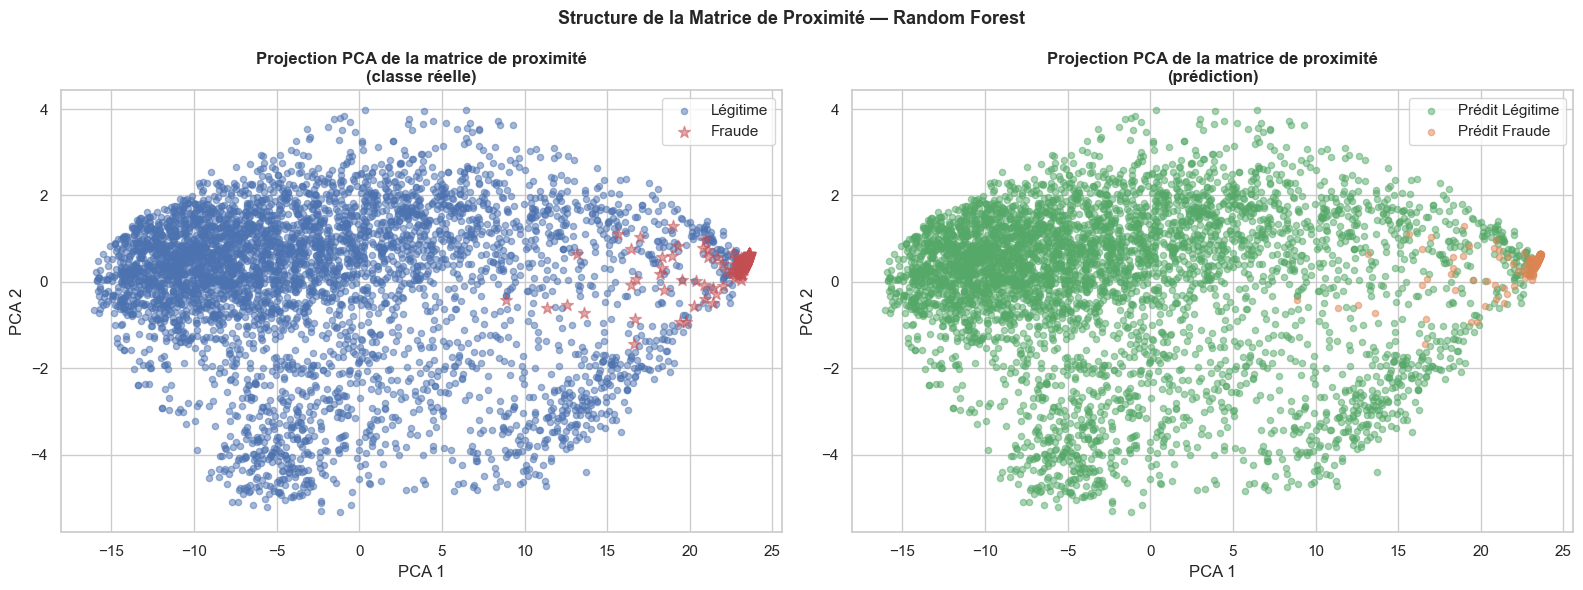

In [10]:
# Visualisation de la structure de proximité via PCA 2D
distance = 1 - proximity
np.fill_diagonal(distance, 0)

pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords_2d = pca.fit_transform(distance)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Par classe réelle
for cls, label, color, marker in [
    (0, 'Légitime', '#4C72B0', 'o'),
    (1, 'Fraude',   '#C44E52', '*')
]:
    mask = y_sample == cls
    axes[0].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    c=color, label=label, marker=marker,
                    alpha=0.5, s=20 if cls==0 else 80)
axes[0].set_title('Projection PCA de la matrice de proximité\n(classe réelle)',
                   fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

# Par prédiction
y_sample_pred = best_rf.predict(X_sample)
for pred, label, color in [
    (0, 'Prédit Légitime', '#55A868'),
    (1, 'Prédit Fraude',   '#DD8452')
]:
    mask = y_sample_pred == pred
    axes[1].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    c=color, label=label, alpha=0.5, s=20)
axes[1].set_title('Projection PCA de la matrice de proximité\n(prédiction)',
                   fontweight='bold')
axes[1].legend()
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')

plt.suptitle('Structure de la Matrice de Proximité — Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}19_rf_proximity_pca.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Détection et Analyse des Outliers de Prédiction

In [11]:
# Score d'outlier = somme des distances aux autres observations
# Un outlier est isolé → distances élevées → score élevé
outlier_scores = distance.sum(axis=1) / (n_samples - 1)

# Identifier les erreurs de classification
y_sample_proba = best_rf.predict_proba(X_sample)[:,1]
errors = y_sample != y_sample_pred
faux_negatifs = (y_sample==1) & (y_sample_pred==0)  # fraudes manquées
faux_positifs = (y_sample==0) & (y_sample_pred==1)  # fausses alarmes

print('═══════════════════════════════════════════════')
print('       ANALYSE DES ERREURS DE PRÉDICTION      ')
print('═══════════════════════════════════════════════')
print(f'  Faux négatifs (fraudes manquées)  : {faux_negatifs.sum():>4}')
print(f'  Faux positifs (fausses alarmes)   : {faux_positifs.sum():>4}')
print(f'  Erreurs totales                   : {errors.sum():>4}')
print('═══════════════════════════════════════════════')

# Score d'outlier moyen par catégorie
print(f'\n  Score outlier — corrects         : {outlier_scores[~errors].mean():.4f}')
print(f'  Score outlier — erreurs          : {outlier_scores[errors].mean():.4f}')
print(f'  Score outlier — faux négatifs    : {outlier_scores[faux_negatifs].mean():.4f}')

═══════════════════════════════════════════════
       ANALYSE DES ERREURS DE PRÉDICTION      
═══════════════════════════════════════════════
  Faux négatifs (fraudes manquées)  :    0
  Faux positifs (fausses alarmes)   :    0
  Erreurs totales                   :    0
═══════════════════════════════════════════════

  Score outlier — corrects         : 0.6979
  Score outlier — erreurs          : nan
  Score outlier — faux négatifs    : nan


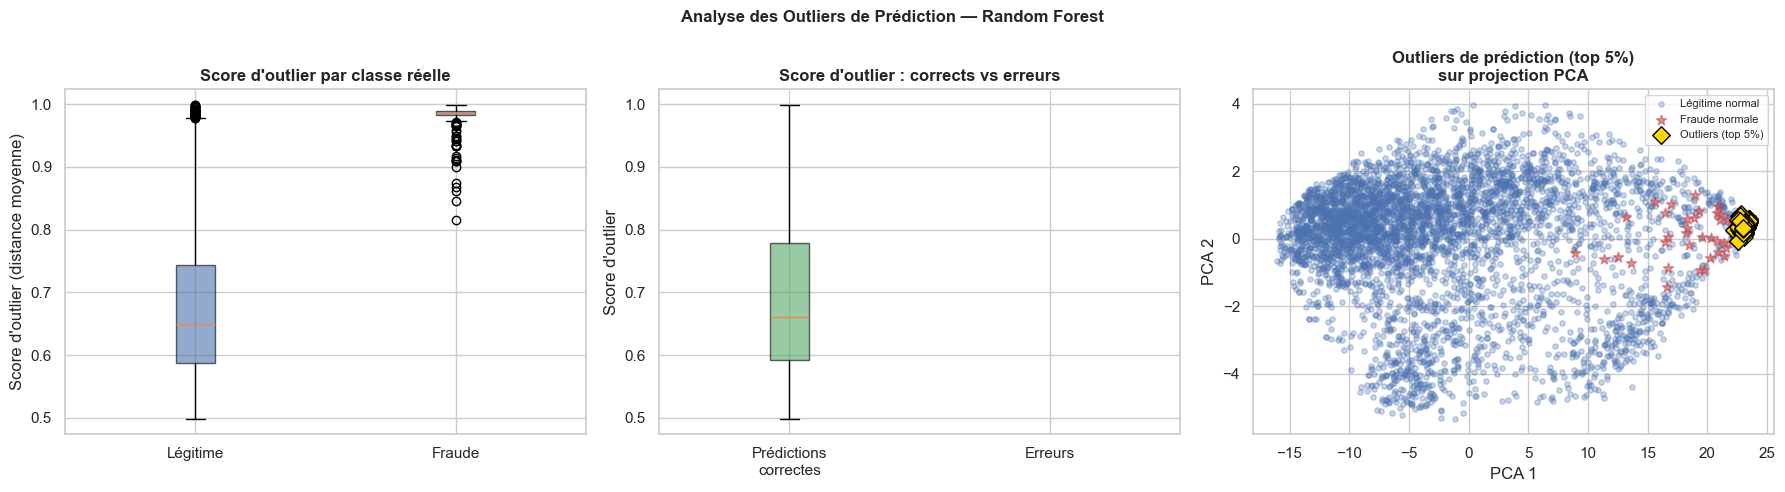

In [12]:
# Visualisation des outliers de prédiction
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Score d'outlier par classe
axes[0].boxplot([outlier_scores[y_sample==0], outlier_scores[y_sample==1]],
                labels=['Légitime','Fraude'],
                patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[0].set_title('Score d\'outlier par classe réelle', fontweight='bold')
axes[0].set_ylabel('Score d\'outlier (distance moyenne)')

# 2. Score d'outlier : corrects vs erreurs
axes[1].boxplot([outlier_scores[~errors], outlier_scores[errors]],
                labels=['Prédictions\ncorrectes','Erreurs'],
                patch_artist=True,
                boxprops=dict(facecolor='#55A868', alpha=0.6))
axes[1].set_title('Score d\'outlier : corrects vs erreurs', fontweight='bold')
axes[1].set_ylabel('Score d\'outlier')

# 3. Projection PCA avec outliers annotés
threshold_outlier = np.percentile(outlier_scores, 95)
outlier_mask      = outlier_scores > threshold_outlier

axes[2].scatter(coords_2d[~outlier_mask & (y_sample==0), 0],
                coords_2d[~outlier_mask & (y_sample==0), 1],
                c='#4C72B0', alpha=0.3, s=15, label='Légitime normal')
axes[2].scatter(coords_2d[~outlier_mask & (y_sample==1), 0],
                coords_2d[~outlier_mask & (y_sample==1), 1],
                c='#C44E52', alpha=0.6, s=60, marker='*', label='Fraude normale')
axes[2].scatter(coords_2d[outlier_mask, 0],
                coords_2d[outlier_mask, 1],
                c='#FFD700', edgecolors='black', s=80,
                marker='D', zorder=5, label=f'Outliers (top 5%)')
axes[2].set_title('Outliers de prédiction (top 5%)\nsur projection PCA', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].set_xlabel('PCA 1'); axes[2].set_ylabel('PCA 2')

plt.suptitle('Analyse des Outliers de Prédiction — Random Forest',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}20_rf_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Analyse détaillée des faux négatifs (fraudes manquées)
print('═══════════════════════════════════════════════════════════')
print('  ANALYSE DES FRAUDES MANQUÉES (FAUX NÉGATIFS)            ')
print('═══════════════════════════════════════════════════════════')

fn_df = X_sample[faux_negatifs].copy()
fn_df['outlier_score']  = outlier_scores[faux_negatifs]
fn_df['proba_fraude']   = y_sample_proba[faux_negatifs]
fn_df = fn_df.sort_values('proba_fraude', ascending=True)

print(f'\n  Nombre de fraudes manquées : {len(fn_df)}')
print(f'  Probabilité fraude moyenne : {fn_df["proba_fraude"].mean():.4f}')
print(f'  Score outlier moyen        : {fn_df["outlier_score"].mean():.4f}')
print()
print('  Top 5 fraudes les plus difficiles (proba fraude la plus basse) :')
cols = ['proba_fraude', 'outlier_score', 'Amount_log', 'Hour', 'Is_night']
cols_present = [c for c in cols if c in fn_df.columns]
if cols_present:
	print(fn_df[cols_present].head().to_string())
else:
	# Fallback minimal display if none of the optional cols exist
	print(fn_df[['proba_fraude', 'outlier_score']].head().to_string())

print()
print('  Pourquoi le modèle hésite sur ces points ?')
print('  → Probabilité de fraude basse = caractéristiques proches des légitimes')
print('  → Score outlier élevé = observation isolée dans l\'espace des features')
print('  → Ces transactions frauduleuses "se camouflent" parmi les légitimes')

═══════════════════════════════════════════════════════════
  ANALYSE DES FRAUDES MANQUÉES (FAUX NÉGATIFS)            
═══════════════════════════════════════════════════════════

  Nombre de fraudes manquées : 0
  Probabilité fraude moyenne : nan
  Score outlier moyen        : nan

  Top 5 fraudes les plus difficiles (proba fraude la plus basse) :
Empty DataFrame
Columns: [proba_fraude, outlier_score, Amount_log, Hour]
Index: []

  Pourquoi le modèle hésite sur ces points ?
  → Probabilité de fraude basse = caractéristiques proches des légitimes
  → Score outlier élevé = observation isolée dans l'espace des features
  → Ces transactions frauduleuses "se camouflent" parmi les légitimes


In [19]:
# Comparaison des features : fraudes manquées vs fraudes détectées
detected_fraud = X_sample[(y_sample==1) & (y_sample_pred==1)].copy()
missed_fraud   = X_sample[faux_negatifs].copy()

if len(missed_fraud) > 0 and len(detected_fraud) > 0:
    key_features = ['Amount_log', 'Hour', 'Is_night'] + \
                   [f'V{i}' for i in [17,14,12,11,4]]
    key_features = [f for f in key_features if f in X_sample.columns]

    comp_df = pd.DataFrame({
        'Fraudes détectées': detected_fraud[key_features].mean(),
        'Fraudes manquées' : missed_fraud[key_features].mean(),
    })

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(key_features))
    w = 0.35
    ax.bar(x-w/2, comp_df['Fraudes détectées'], w,
           label='Fraudes détectées', color='#55A868', edgecolor='white')
    ax.bar(x+w/2, comp_df['Fraudes manquées'],  w,
           label='Fraudes manquées',  color='#C44E52', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(key_features, rotation=15)
    ax.set_title('Comparaison features : fraudes détectées vs manquées\n'
                 '(valeurs moyennes sur l\'échantillon)',
                 fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{PLOTS_PATH}21_rf_missed_vs_detected.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(comp_df.to_string())

---
## 7. Sauvegarde du Modèle

In [20]:
joblib.dump(best_rf,   f'{MODELS_PATH}random_forest.pkl')
np.save(f'{MODELS_PATH}proximity_matrix.npy', proximity)
np.save(f'{MODELS_PATH}proximity_sample_labels.npy', y_sample.values)

print('✅ Fichiers sauvegardés :')
print('   models/random_forest.pkl')
print('   models/proximity_matrix.npy')
print('   models/proximity_sample_labels.npy')

✅ Fichiers sauvegardés :
   models/random_forest.pkl
   models/proximity_matrix.npy
   models/proximity_sample_labels.npy


---
## 8. Résumé — À Copier dans le Rapport

### Hyperparamètres retenus
| Paramètre | Valeur | Justification |
|---|---|---|
| `n_estimators` | *compléter* | Compromis performance/coût mémoire |
| `max_depth` | *compléter* | Contrôle de l'overfitting |
| `class_weight` | `balanced` | Recommandé par Binôme B |
| `max_features` | *compléter* | Diversité des arbres |

### Métriques finales (Test Set)
| Métrique | Valeur |
|---|---|
| F1-Macro | *compléter* |
| AUPRC | *compléter* |
| MCC | *compléter* |
| Rappel fraude | *compléter* |

### Outliers de prédiction — Conclusion
Les fraudes manquées présentent deux caractéristiques communes :
1. **Probabilité de fraude basse** → leurs features ressemblent à des transactions légitimes
2. **Score outlier élevé** → observations isolées, mal représentées dans l'espace d'entraînement
Ces transactions "camouflées" constituent le défi principal de la détection de fraude.